Name: Premanshu Devendra Kusre  
Roll No: CS23117  
Subject: Machine Learning  
Topic: Network Anomaly Detection  
Dataset: UNSW-NB15  
Model Used: Support Vector Machine (SVM)

AIM

To implement the Support Vector Machine (SVM) algorithm on the UNSW-NB15 dataset
for detecting network anomalies and classifying network traffic.

DATASET DESCRIPTION

The UNSW-NB15 dataset contains network traffic data with both normal and malicious activities.
It includes multiple features such as protocol, service, and statistical attributes.

The target variable is 'label':
0 → Normal traffic
1 → Attack / anomaly

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# Load dataset

df = pd.read_csv("/content/drive/MyDrive/ML Dataset/UNSW_NB15_training-set.csv")

In [26]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [27]:
df.shape

(82332, 45)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [29]:
df['label'].value_counts()

,count
label,
1,45332
0,37000


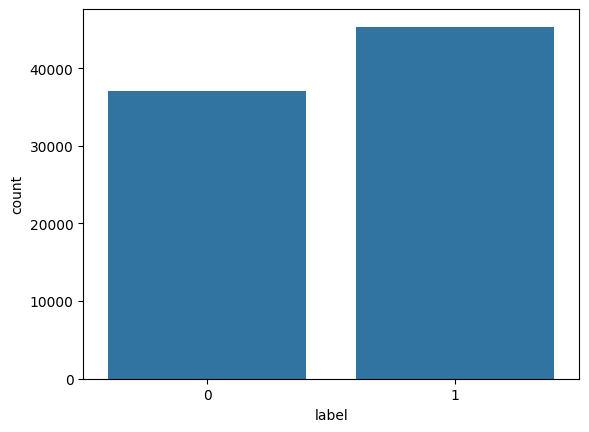

In [30]:
sns.countplot(x='label', data=df)
plt.show()

In [31]:
encoder = LabelEncoder()

df['proto'] = encoder.fit_transform(df['proto'])
df['service'] = encoder.fit_transform(df['service'])
df['state'] = encoder.fit_transform(df['state'])

In [32]:
df = df.drop(['attack_cat'], axis=1)

In [33]:
X = df.drop('label', axis=1)
y = df['label']

FEATURE SCALING

Feature scaling is applied because SVM is sensitive to the scale of input features.
StandardScaler is used to normalize the data for better performance.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (65865, 43)
Testing shape: (16467, 43)


MODEL IMPLEMENTATION

In this section, the Support Vector Machine algorithm is implemented
to classify network traffic as normal or anomalous.

In [37]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(max_iter=3000)

svm_model.fit(X_train, y_train)

LinearSVC(max_iter=3000)

In [38]:
y_pred = svm_model.predict(X_test)

In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy: {:.2f}%".format(accuracy * 100))

SVM Accuracy: 94.77%


In [40]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[6984  434]
 [ 427 8622]]


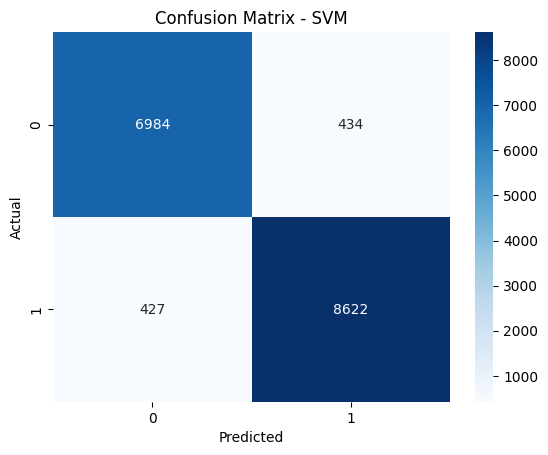

In [41]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7418
           1       0.95      0.95      0.95      9049

    accuracy                           0.95     16467
   macro avg       0.95      0.95      0.95     16467
weighted avg       0.95      0.95      0.95     16467



RESULT

The SVM model was successfully implemented on the UNSW-NB15 dataset.

Feature scaling was applied to improve model performance.
The model performed well in detecting anomalies, although Random Forest
showed better performance and faster training.

SVM is effective but computationally more expensive for large datasets.